In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter
import scienceplots # 导入SciencePlots

# --- 设置绘图风格 ---
# 使用'science'和'ieee'风格，适用于IEEE出版物
plt.style.use(['science', 'ieee'])
# 设置字体为Times New Roman
plt.rcParams['font.serif'] = ['Times New Roman']
# 设置保存图像的DPI和负号显示
mpl.rcParams['figure.dpi'] = 800
# 允许显示负号
mpl.rcParams['axes.unicode_minus'] = False


# 手动设置科学计数法格式，用于对数坐标轴
import matplotlib.ticker as mtick

def log_tick_formatter(val, pos=None):
    if val == 0:
        return "0"
    exp = np.log10(val)
    # 若为整数指数 -> 主要刻度
    if np.isclose(exp, int(exp), atol=1e-6):
        exp = int(exp)
        if exp == 0:
            return "$1$"
        return rf"$10^{{{exp}}}$"
    # 其它次要刻度不显示
    return ""

In [5]:
# 设置随机种子以确保结果可重现
torch.manual_seed(451)
np.random.seed(451)

# --- 参数设置 ---
Nx = 1000    # 输入数据长度
input_data = torch.randn(Nx, 1) # 信号x_k,标准高斯分布


# RLS算法正则化参数
regularization_param = 0.01

# 子系统中噪声尺度参数,网格化寻优
S = torch.cat([torch.tensor([0.01, 0.05]), torch.arange(0.1, 5.0, 0.05)])
NumS = len(S)

# 存储三种N值的结果
N_values = [1, 2, 10, 31, 61]
results = {}

# --- 对每个N值运行实验 ---
for N in N_values:
    print(f"\n处理 N = {N}...")
    
    MSE_array = torch.zeros(NumS)
    Thetas = torch.zeros(N, 1)
    
    best_mse = float('inf')
    best_noise_idx = 0
    best_instantaneous_mse = torch.zeros(Nx)  # ← 改成初始化为零张量
    best_msd_curve = None
    best_predictions = None
    best_weights_evolution = None
    
    # 测试不同噪声尺度
    for i in range(NumS):
        # 为当前噪声尺度重新初始化RLS算法参数
        w = torch.ones(N, 1)
        P = torch.eye(N)
        torch.manual_seed(451 + 3 * i)
        # 生成当前噪声尺度下的噪声张量
        Noise = S[i] * torch.randn(Nx, N)
        
        # 计算阈值系统输出
        input_expanded = input_data.repeat(1, N)
        thetas_expanded = Thetas.T.repeat(Nx, 1)
        
        # 强制符号函数输出±1
        yout = torch.where(input_expanded + Noise - thetas_expanded >= 0,
                           torch.ones_like(input_expanded),
                           -torch.ones_like(input_expanded)).T # N x Nx
        
        # 为当前噪声尺度创建临时数组
        current_instantaneous_mse = torch.zeros(Nx)
        current_msd = torch.zeros(Nx)
        current_y_hat = torch.zeros(Nx)
        current_weights = torch.zeros(Nx, N)
        
        for j in range(Nx):
            y = yout[:, j].reshape(N, 1) # N x 1
            
            # RLS算法更新
            denominator = y.T @ P @ y + regularization_param
            g = (P @ y) / denominator
            
            error = input_data[j, 0] - y.T @ w
            
            current_instantaneous_mse[j] = error.item() ** 2  
            w = w + g * error
            
            P = P - g @ y.T @ P
            
            # 记录数据(对N=31保存详细数据,其他只保存必要数据)
            current_y_hat[j] = (y.T @ w).item()
            
            if N == 31:
                current_msd[j] = torch.trace(P)
                current_weights[j] = w.flatten()
        
        # 计算当前噪声尺度下的最终MSE
        final_mse = torch.mean((input_data[:, 0] - current_y_hat)**2)
        MSE_array[i] = final_mse
        
        # 如果当前结果更好,保存为最优结果
        if final_mse < best_mse:
            best_mse = final_mse
            best_noise_idx = i
            best_instantaneous_mse = current_instantaneous_mse.clone()
            if N == 31:
                best_msd_curve = current_msd.clone()
                best_predictions = current_y_hat.clone()
                best_weights_evolution = current_weights.clone()
    
    # 保存结果
    results[N] = {
        'MSE_array': MSE_array,
        'best_mse': best_mse,
        'best_noise_idx': best_noise_idx,
        'best_S': S[best_noise_idx].item(),
        'instantaneous_mse': best_instantaneous_mse  # 添加这行，对所有N都保存
    }
    
    if N == 31:
        results[N]['msd_curve'] = best_msd_curve
        results[N]['predictions'] = best_predictions
        results[N]['weights_evolution'] = best_weights_evolution
    
    print(f"N={N}: 最优MSE={best_mse:.6f}, 最优噪声尺度S={S[best_noise_idx]:.3f}")

# 提取数据用于绘图
MSE_LMS2 = results[2]['MSE_array']
best_mse2 = results[2]['best_mse']
best_noise_idx2 = results[2]['best_noise_idx']

MSE_LMS10 = results[10]['MSE_array']
best_mse10 = results[10]['best_mse']
best_noise_idx10 = results[10]['best_noise_idx']

MSE_LMS = results[31]['MSE_array']
best_mse = results[31]['best_mse']
best_noise_idx = results[31]['best_noise_idx']
best_msd_curve = results[31]['msd_curve']
best_predictions = results[31]['predictions']
best_weights_evolution = results[31]['weights_evolution']

MSE_LMS61 = results[61]['MSE_array']
best_mse61 = results[61]['best_mse']
best_noise_idx61 = results[61]['best_noise_idx']


处理 N = 1...
N=1: 最优MSE=0.376893, 最优噪声尺度S=0.010

处理 N = 2...
N=2: 最优MSE=0.333488, 最优噪声尺度S=0.300

处理 N = 10...
N=10: 最优MSE=0.176180, 最优噪声尺度S=0.750

处理 N = 31...
N=31: 最优MSE=0.096049, 最优噪声尺度S=0.950

处理 N = 61...
N=61: 最优MSE=0.057367, 最优噪声尺度S=1.300


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


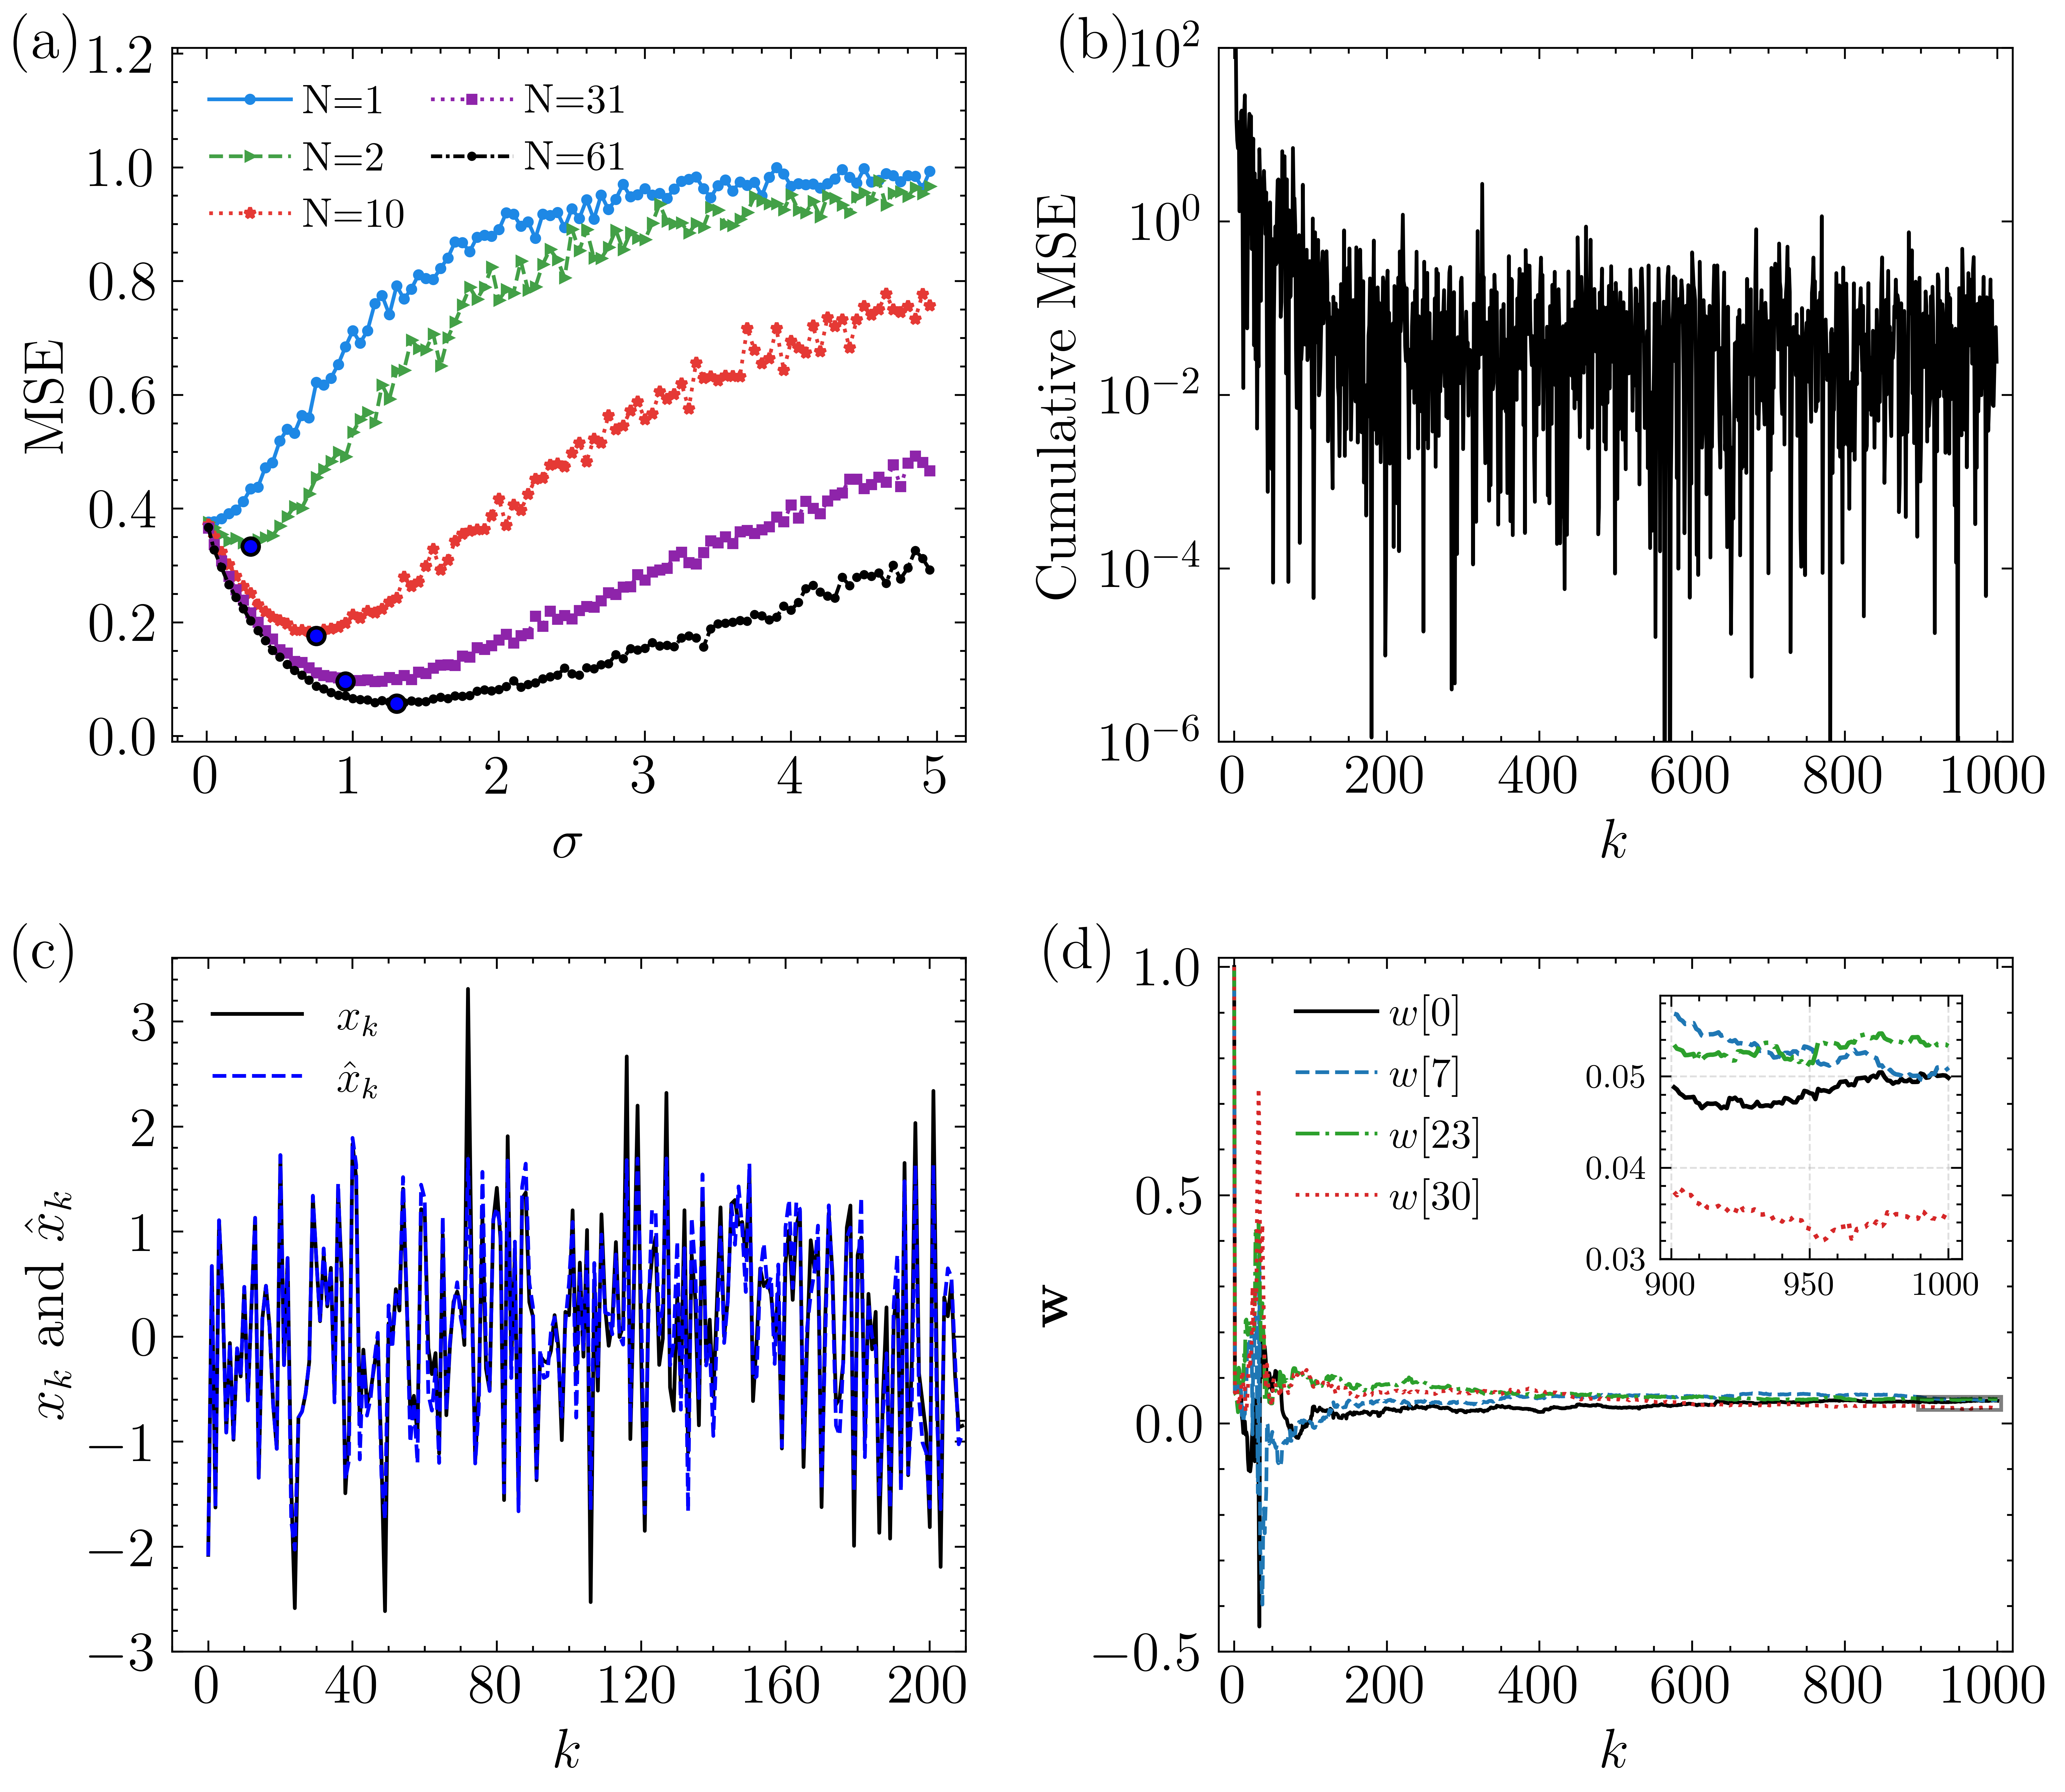


最终结果摘要:
N=  1: 最优MSE=0.376893, 最优噪声尺度S=0.010
N=  2: 最优MSE=0.333488, 最优噪声尺度S=0.300
N= 10: 最优MSE=0.176180, 最优噪声尺度S=0.750
N= 31: 最优MSE=0.096049, 最优噪声尺度S=0.950
N= 61: 最优MSE=0.057367, 最优噪声尺度S=1.300


In [13]:
N = 31  # 用于权重图

# --- 绘图 ---
plt.rcParams.update({
    'font.size': 14,          # 基础字体大小
    'axes.labelsize': 15,      # 坐标轴标签
    'axes.titlesize': 15,      # 子图标题
    'xtick.labelsize': 15,     # x轴刻度
    'ytick.labelsize': 15,     # y轴刻度
    'legend.fontsize': 15,     # 图例
    'figure.titlesize': 15     # 图形标题
})

fig1, axes = plt.subplots(2, 2, figsize=(8, 7))
axes = axes.flatten()

# 子图标签
subplot_labels = ['(a)', '(b)', '(c)', '(d)']

# 子图1：MSE vs 噪声尺度 - 修改这里
colors = [
    '#1E88E5',  # 明亮蓝
    '#43A047',  # 鲜绿
    '#E53935',  # 鲜红
    '#8E24AA',  # 紫罗兰
    '#FB8C00'   # 橙黄
]



linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))] 
MSE_LMS1 = results[1]['MSE_array']
MSE_LMS2 = results[2]['MSE_array']

ax = axes[0]
ax.plot(S.numpy(), MSE_LMS1.numpy(), linestyle=linestyles[0], color=colors[0], marker='o', markersize=2, label='N=1')
ax.plot(S.numpy(), MSE_LMS2.numpy(), linestyle=linestyles[1], color=colors[1], marker='>', markersize=2, label='N=2')
ax.plot(S.numpy(), MSE_LMS10.numpy(), linestyle=linestyles[3], color=colors[2], marker='*', markersize=3, label='N=10')
ax.plot(S.numpy(), MSE_LMS.numpy(), linestyle=linestyles[3], color=colors[3], marker='s', markersize=2, label='N=31')
ax.plot(S.numpy(), MSE_LMS61.numpy(), linestyle=linestyles[4], color='black', marker='.', markersize=3, label='N=61')

# best MSD markers：大一点 + 用相同颜色体系
ax.scatter(S[best_noise_idx2].numpy(), best_mse2.numpy(), color='blue', s=20, zorder=5, edgecolors='black')
ax.scatter(S[best_noise_idx10].numpy(), best_mse10.numpy(), color='blue', s=20, zorder=5, edgecolors='black')
ax.scatter(S[best_noise_idx].numpy(),   best_mse.numpy(),   color='blue', s=20, zorder=5, edgecolors='black')
ax.scatter(S[best_noise_idx61].numpy(), best_mse61.numpy(), color='blue', s=20, zorder=5, edgecolors='black')

ax.set_xlabel(r'$\sigma$')
ax.set_ylabel('MSE')
ax.set_ylim([-0.01,1.21])
ax.set_yticks(np.arange(0,1.21,0.2)) 
ax.set_xticks(np.arange(0,6,1))  
ax.legend(
    loc='upper left',
    #bbox_to_anchor=(0.7, 1.0),
    ncol=2, 
    fontsize = 11,    
    columnspacing=0.6,
    handletextpad=0.3
)
ax.grid(False)
ax.text(-0.2, 1.05, subplot_labels[0], transform=ax.transAxes, 
        fontsize=16, fontweight='bold', va='top')
# 子图2：累积平均MSE
# 子图2：累积平均MSE
ax = axes[1]
instantaneous_errors_squared = best_instantaneous_mse.numpy()
# 计算累积平均
cumulative_mse = np.cumsum(instantaneous_errors_squared) / np.arange(1, Nx+1)

ax.plot(instantaneous_errors_squared)
ax.set_xlabel(r'$k$')
ax.set_ylabel(r'Cumulative MSE')
ax.set_xticks(np.arange(0, 1020, 200)) 
ax.set_xlim([-20,1020])
ax.set_yscale('log')
ax.set_ylim([1e-6,1e+2])
ax.grid(False)
ax.text(-0.20, 1.05, subplot_labels[1], transform=ax.transAxes, 
        fontsize=16, fontweight='bold', va='top')
# 子图3：信号拟合效果对比(前100个点)
ax = axes[2]
sample_range = slice(0, min(210, Nx))
sample_indices = np.arange(len(input_data[sample_range, 0]))
ax.plot(sample_indices, input_data[sample_range, 0].numpy(), label= r'$x_k$')
ax.plot(sample_indices, best_predictions[sample_range].numpy(), color='blue', linestyle='--', label= r'$\hat{x}_k$')
ax.set_xlabel(r'$k$')
ax.set_ylabel(r'$x_k$ and $\hat{x}_k$')
yticks = [-3.0,-2.0, -1.0, 0, 1.0, 2.0,3.0]
ax.set_yticks(yticks)
ax.set_xlim([-10, 210])
ax.set_xticks(np.arange(0,211,40))  
ax.legend(loc='upper left', fontsize = 12)
ax.grid(False)
ax.text(-0.2, 1.05, subplot_labels[2], transform=ax.transAxes, 
        fontsize=16, fontweight='bold', va='top')

# 子图4：权重向量演化
ax = axes[3]
colors = ['k', '#1f77b4', '#2ca02c', '#d62728']
line_styles = ['-', '--', '-.', ':']

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

N_val = N
weight_indices = [0, N_val//4, 3*N_val//4, N_val-1] if N_val >= 5 \
                 else [0, N_val//2, N_val-1] if N_val >= 3 else [0]

# =========================
# 主图
# =========================
for i, idx in enumerate(weight_indices):
    w_series = best_weights_evolution[:, idx].numpy()
    w_series = np.concatenate(([1.0], w_series))   # prepend initial w=1

    ax.plot(
        w_series,
        label=f'$w[{idx}]$',
        linestyle=line_styles[i % len(line_styles)],
        linewidth=1.0,
        color=colors[i % len(colors)]
    )

ax.set_xlabel(r'$k$')
ax.set_ylabel(r'$\mathbf{w}$')
ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=8))
ax.set_xticks(np.arange(0, 1020, 200))
ax.set_xlim([-20,1020])
ax.set_ylim([-0.5, 1.02])
ax.set_yticks([-0.5, 0, 0.5, 1.0])
ax.grid(False)

ax.legend(
    loc='upper left',
    ncol=1,
    bbox_to_anchor=(0.05, 1.0),   # ← 向右移动
    fontsize=11,
    columnspacing=0.6,
    handletextpad=0.3
)

ax.text(
    -0.22, 1.05, subplot_labels[3],
    transform=ax.transAxes,
    fontsize=16, fontweight='bold', va='top'
)

# =========================
# 插图：放大最后 100 个点
# =========================
axins = inset_axes(
    ax,
    width="38%",
    height="38%",
    loc='upper left',
    bbox_to_anchor=(0.5, 0.01, 1.0, 1.0),  # ← y 从 0.95 大幅降到 0.78
    bbox_transform=ax.transAxes,
    borderpad=0.8
)


zoom_len = 100

for i, idx in enumerate(weight_indices):
    w_series = best_weights_evolution[:, idx].numpy()
    w_series = np.concatenate(([1.0], w_series))

    axins.plot(
        np.arange(len(w_series) - zoom_len, len(w_series)),
        w_series[-zoom_len:],
        linestyle=line_styles[i % len(line_styles)],
        linewidth=1.2,
        color=colors[i % len(colors)]
    )

# 自动设置插图 y 轴范围（突出收敛）
w_zoom_all = np.concatenate([
    np.concatenate(([1.0], best_weights_evolution[:, idx].numpy()))[-zoom_len:]
    for idx in weight_indices
])

margin = 0.08 * (w_zoom_all.max() - w_zoom_all.min())
axins.set_ylim(w_zoom_all.min() - margin, w_zoom_all.max() + margin)

axins.tick_params(axis='both', labelsize=9)
axins.grid(True, linestyle='--', alpha=0.4)

# 在主图上标明放大区域（期刊加分项）
ax.indicate_inset_zoom(axins, edgecolor='black', linewidth=1.0)
import warnings
warnings.filterwarnings('ignore', message='This figure includes Axes that are not compatible with tight_layout')
fig1.tight_layout()
fig1.savefig('D:/IEEE 2025 Adaptive weighted SSR/Fig3.eps', format='eps', dpi=800, bbox_inches='tight')
plt.show()

# 打印最终结果摘要
print("\n" + "="*60)
print("最终结果摘要:")
print("="*60)
for N_val in N_values:
    res = results[N_val]
    print(f"N={N_val:3d}: 最优MSE={res['best_mse']:.6f}, 最优噪声尺度S={res['best_S']:.3f}")
print("="*60)

In [2]:
num_runs = 20

# --- 参数设置 ---
Nx = 1000    # 输入数据长度

# RLS算法正则化参数
regularization_param = 0.01

# 子系统中噪声尺度参数,网格化寻优
S = torch.cat([torch.tensor([0.01, 0.05]), torch.arange(0.1, 5.0, 0.05)])
NumS = len(S)

# 存储三种N值的结果
N_values = [1, 2, 10, 31, 61]
results = {}
results_mc = {}

for N in N_values:
    print(f"\n====== N = {N} ======")

    best_mse_runs = torch.zeros(num_runs)
    best_S_runs   = torch.zeros(num_runs)

    for run in range(num_runs):
        print(f"  Run {run+1}/{num_runs}")

        MSE_array = torch.zeros(NumS)
        Thetas = torch.zeros(N, 1)

        best_mse = float('inf')
        best_noise_idx = 0
        seed = 450 + run
        torch.manual_seed(seed)
        np.random.seed(seed)

    # --- 生成本 run 的输入信号 ---
        input_data = torch.randn(Nx, 1)


        # 扫描不同 S
        for i in range(NumS):
            w = torch.ones(N, 1)
            P = torch.eye(N)
            seed = 450 + run + i
            torch.manual_seed(seed)
            np.random.seed(seed)

            Noise = S[i] * torch.randn(Nx, N)

            input_expanded = input_data.repeat(1, N)
            thetas_expanded = Thetas.T.repeat(Nx, 1)

            yout = torch.where(
                input_expanded + Noise - thetas_expanded >= 0,
                torch.ones_like(input_expanded),
                -torch.ones_like(input_expanded)
            ).T  # N x Nx

            current_y_hat = torch.zeros(Nx)

            for j in range(Nx):
                y = yout[:, j].reshape(N, 1)

                denominator = y.T @ P @ y + regularization_param
                g = (P @ y) / denominator

                error = input_data[j, 0] - y.T @ w
                w = w + g * error
                P = P - g @ y.T @ P

                current_y_hat[j] = (y.T @ w).item()

            final_mse = torch.mean((input_data[:, 0] - current_y_hat) ** 2)
            MSE_array[i] = final_mse

            if final_mse < best_mse:
                best_mse = final_mse
                best_noise_idx = i

        best_mse_runs[run] = best_mse
        best_S_runs[run]   = S[best_noise_idx]

    # === Monte Carlo 统计 ===
    results_mc[N] = {
        "MSE_mean": best_mse_runs.mean().item(),
        "MSE_std":  best_mse_runs.std(unbiased=True).item(),
        "S_mean":   best_S_runs.mean().item(),
        "S_std":    best_S_runs.std(unbiased=True).item(),
    }

    print(
        f"N={N}: "
        f"MSE = {results_mc[N]['MSE_mean']:.4e} ± {results_mc[N]['MSE_std']:.4e}, "
        f"S* = {results_mc[N]['S_mean']:.3f} ± {results_mc[N]['S_std']:.3f}"
    )


====== N = 1 ======
  Run 1/20
  Run 2/20
  Run 3/20
  Run 4/20
  Run 5/20
  Run 6/20
  Run 7/20
  Run 8/20
  Run 9/20
  Run 10/20
  Run 11/20
  Run 12/20
  Run 13/20
  Run 14/20
  Run 15/20
  Run 16/20
  Run 17/20
  Run 18/20
  Run 19/20
  Run 20/20
N=1: MSE = 3.5997e-01 ± 1.9006e-02, S* = 0.010 ± 0.000

====== N = 2 ======
  Run 1/20
  Run 2/20
  Run 3/20
  Run 4/20
  Run 5/20
  Run 6/20
  Run 7/20
  Run 8/20
  Run 9/20
  Run 10/20
  Run 11/20
  Run 12/20
  Run 13/20
  Run 14/20
  Run 15/20
  Run 16/20
  Run 17/20
  Run 18/20
  Run 19/20
  Run 20/20
N=2: MSE = 3.2076e-01 ± 1.9036e-02, S* = 0.282 ± 0.052

====== N = 10 ======
  Run 1/20
  Run 2/20
  Run 3/20
  Run 4/20
  Run 5/20
  Run 6/20
  Run 7/20
  Run 8/20
  Run 9/20
  Run 10/20
  Run 11/20
  Run 12/20
  Run 13/20
  Run 14/20
  Run 15/20
  Run 16/20
  Run 17/20
  Run 18/20
  Run 19/20
  Run 20/20
N=10: MSE = 1.6941e-01 ± 1.0501e-02, S* = 0.715 ± 0.073

====== N = 31 ======
  Run 1/20
  Run 2/20
  Run 3/20
  Run 4/20
  Run 5/20


In [4]:
import torch
# 设置随机种子以确保结果可重现
torch.manual_seed(451)
np.random.seed(451)

# --- 参数设置 ---
Nx = 1000    # 输入数据长度
input_data = torch.randn(Nx, 1) # 信号x_k,标准高斯分布


# RLS算法正则化参数
regularization_param = 0.01

# 子系统中噪声尺度参数,网格化寻优
S = torch.cat([torch.tensor([0.01, 0.05]), torch.arange(0.1, 5.0, 0.05)])
NumS = len(S)

# 存储三种N值的结果
N_values = [1, 2, 10, 31, 61]
results = {}

# --- 对每个N值运行实验 ---
for N in N_values:
    print(f"\n处理 N = {N}...")
    
    MSE_array = torch.zeros(NumS)
    Thetas = torch.zeros(N, 1)
    
    best_mse = float('inf')
    best_noise_idx = 0
    best_instantaneous_mse = torch.zeros(Nx)  # ← 改成初始化为零张量
    best_msd_curve = None
    best_predictions = None
    best_weights_evolution = None
    
    # 测试不同噪声尺度
    for i in range(NumS):
        # 为当前噪声尺度重新初始化RLS算法参数
            # 注意：w和P现在都是标量
        # 初始权重设为1/N，因为y_k的量级约为sqrt(N)到N
        w = torch.tensor(1.0)  # 标量权系数
        P = torch.tensor(1.0)  # 标量协方差
        torch.manual_seed(451+3*i)
        np.random.seed(451+3*i)
        # 生成当前噪声尺度下的噪声张量
        Noise = S[i] * torch.randn(Nx, N)
        
        # 计算阈值系统输出
        input_expanded = input_data.repeat(1, N)
        thetas_expanded = Thetas.T.repeat(Nx, 1)
        
        # 强制符号函数输出±1
        yout = torch.where(input_expanded + Noise - thetas_expanded >= 0,
                           torch.ones_like(input_expanded),
                           -torch.ones_like(input_expanded)).T # N x Nx
        
        # 为当前噪声尺度创建临时数组
        current_instantaneous_mse = torch.zeros(Nx)
        current_msd = torch.zeros(Nx)
        current_y_hat = torch.zeros(Nx)
        current_weights = torch.zeros(Nx, N)
        
        for j in range(Nx):
            # 计算所有子系统输出的和：y_k = sum_{n=1}^{N} y_{n,k}
            y_k = torch.sum(yout[:, j])  # 标量
        
            # 预测输出（使用上一时刻的权重）：x̂_k = y_k * w_{k-1}
            x_hat = y_k * w
        
            # 误差：e_k = x_k - y_k * w_{k-1}
            error = input_data[j, 0] - x_hat
            current_instantaneous_mse[j] = error.item() ** 2 
        
            # RLS算法更新（标量版本）
            # g_k = P_{k-1} * y_k / (y_k^2 * P_{k-1} + δ)
            denominator = y_k**2 * P + regularization_param
            g_k = (P * y_k) / denominator
        
            # 更新权重：w_k = w_{k-1} + g_k * (x_k - y_k * w_{k-1})
            w = w + g_k * error
        
            # 更新协方差：P_k = P_{k-1} - g_k * y_k * P_{k-1}
            P = P - g_k * y_k * P
            
            # 记录数据(对N=31保存详细数据,其他只保存必要数据)
            current_y_hat[j] = (y_k * w).item()
            
            if N == 31:
                instantaneous_error = input_data[j, 0] - current_y_hat[j]
                current_msd[j] = P.item()
                current_weights[j] = w.item()
        
        # 计算当前噪声尺度下的最终MSE
        final_mse = torch.mean((input_data[:, 0] - current_y_hat)**2)
        MSE_array[i] = final_mse
        
        # 如果当前结果更好,保存为最优结果
        if final_mse < best_mse:
            best_mse = final_mse
            best_noise_idx = i
            best_instantaneous_mse = current_instantaneous_mse.clone()
            if N == 31:
                best_msd_curve = current_msd.clone()
                best_predictions = current_y_hat.clone()
                best_weights_evolution = current_weights.clone()
    
    # 保存结果
    results[N] = {
        'MSE_array': MSE_array,
        'best_mse': best_mse,
        'best_noise_idx': best_noise_idx,
        'best_S': S[best_noise_idx].item(),
        'instantaneous_mse': best_instantaneous_mse  # 添加这行，对所有N都保存
    }
    
    if N == 31:
        results[N]['instantaneous_mse'] = best_instantaneous_mse
        results[N]['msd_curve'] = best_msd_curve
        results[N]['predictions'] = best_predictions
        results[N]['weights_evolution'] = best_weights_evolution
    
    print(f"N={N}: 最优MSE={best_mse:.6f}, 最优噪声尺度S={S[best_noise_idx]:.3f}")

# 提取数据用于绘图
MSE_LMS2 = results[2]['MSE_array']
best_mse2 = results[2]['best_mse']
best_noise_idx2 = results[2]['best_noise_idx']

MSE_LMS10 = results[10]['MSE_array']
best_mse10 = results[10]['best_mse']
best_noise_idx10 = results[10]['best_noise_idx']

MSE_LMS = results[31]['MSE_array']
best_mse = results[31]['best_mse']
best_noise_idx = results[31]['best_noise_idx']
best_msd_curve = results[31]['msd_curve']
best_predictions = results[31]['predictions']
best_weights_evolution = results[31]['weights_evolution']

MSE_LMS61 = results[61]['MSE_array']
best_mse61 = results[61]['best_mse']
best_noise_idx61 = results[61]['best_noise_idx']


处理 N = 1...
N=1: 最优MSE=0.376893, 最优噪声尺度S=0.010

处理 N = 2...
N=2: 最优MSE=0.334037, 最优噪声尺度S=0.300

处理 N = 10...
N=10: 最优MSE=0.182630, 最优噪声尺度S=0.750

处理 N = 31...
N=31: 最优MSE=0.105939, 最优噪声尺度S=0.950

处理 N = 61...
N=61: 最优MSE=0.072218, 最优噪声尺度S=1.300


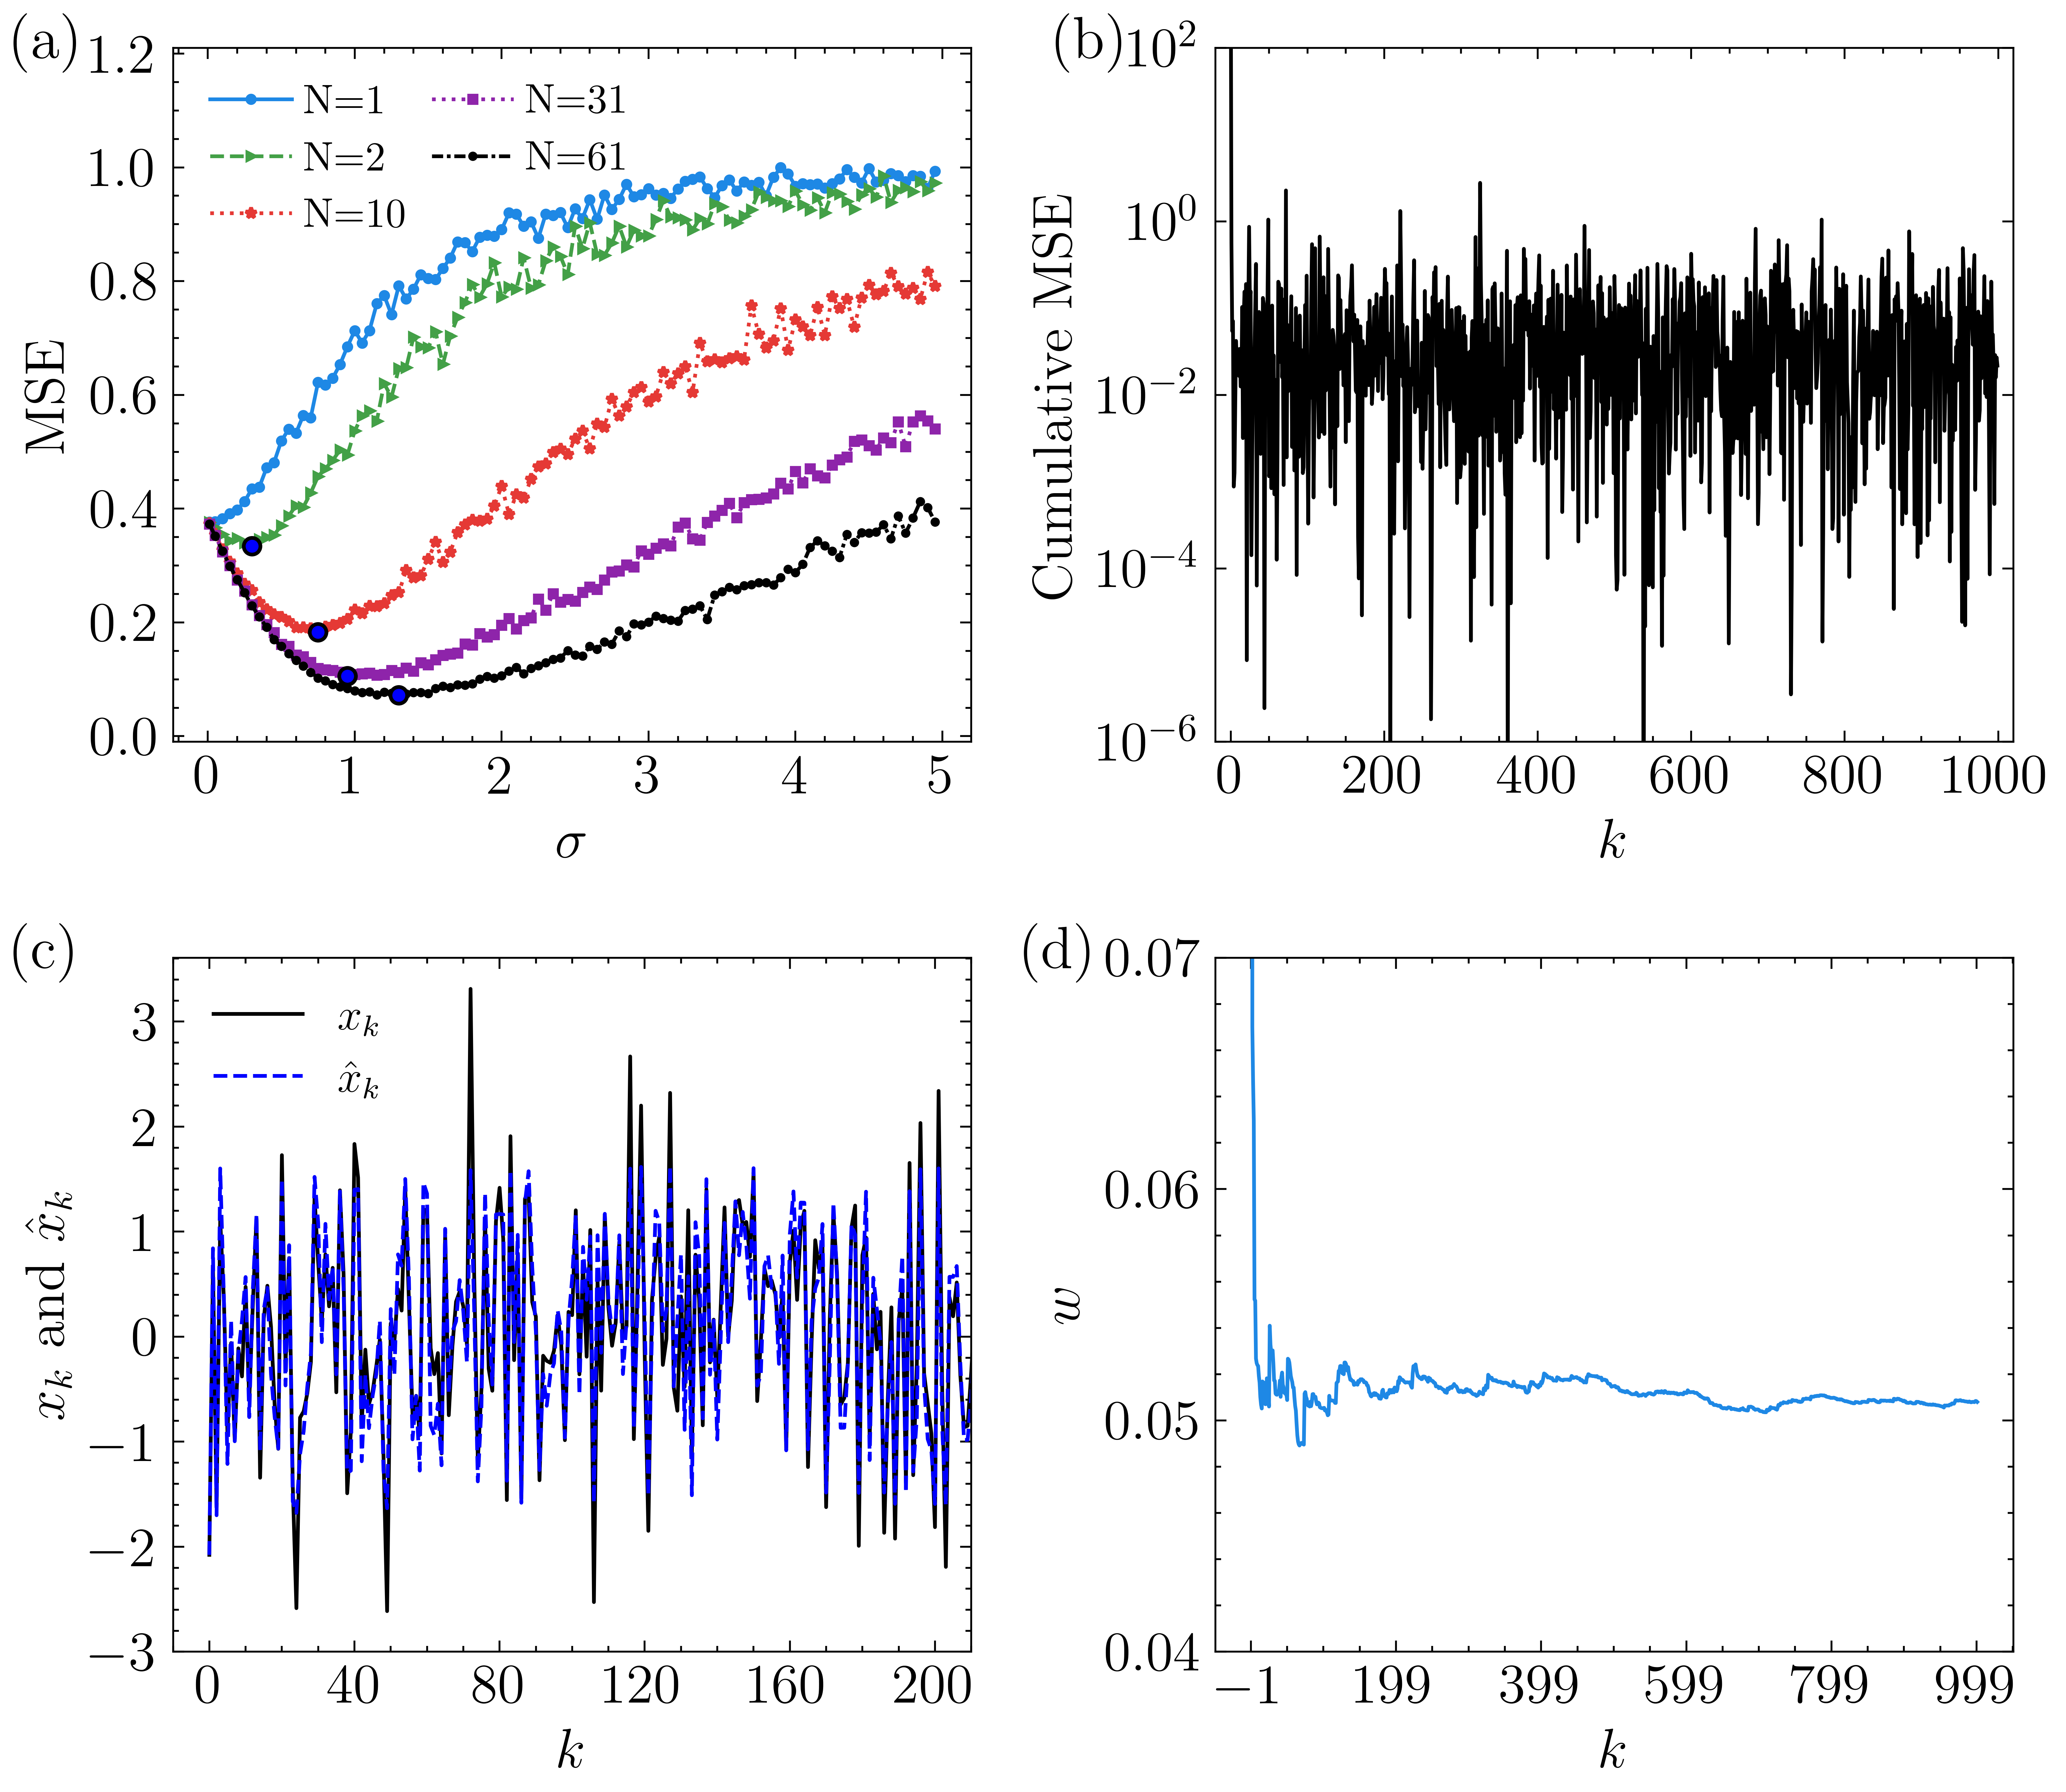


最终结果摘要:
N=  1: 最优MSE=0.376893, 最优噪声尺度S=0.010
N=  2: 最优MSE=0.334037, 最优噪声尺度S=0.300
N= 10: 最优MSE=0.182630, 最优噪声尺度S=0.750
N= 31: 最优MSE=0.105939, 最优噪声尺度S=0.950
N= 61: 最优MSE=0.072218, 最优噪声尺度S=1.300


In [18]:
N = 31  # 用于权重图
import numpy as np
# --- 绘图 ---
plt.rcParams.update({
    'font.size': 14,          # 基础字体大小
    'axes.labelsize': 15,      # 坐标轴标签
    'axes.titlesize': 15,      # 子图标题
    'xtick.labelsize': 15,     # x轴刻度
    'ytick.labelsize': 15,     # y轴刻度
    'legend.fontsize': 15,     # 图例
    'figure.titlesize': 15     # 图形标题
})

fig1, axes = plt.subplots(2, 2, figsize=(8, 7))
axes = axes.flatten()

# 子图标签
subplot_labels = ['(a)', '(b)', '(c)', '(d)']

# 子图1：MSE vs 噪声尺度 - 修改这里
colors = [
    '#1E88E5',  # 明亮蓝
    '#43A047',  # 鲜绿
    '#E53935',  # 鲜红
    '#8E24AA',  # 紫罗兰
    '#FB8C00'   # 橙黄
]



linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))] 
MSE_LMS1 = results[1]['MSE_array']
MSE_LMS2 = results[2]['MSE_array']

ax = axes[0]
ax.plot(S.numpy(), MSE_LMS1.numpy(), linestyle=linestyles[0], color=colors[0], marker='o', markersize=2, label='N=1')
ax.plot(S.numpy(), MSE_LMS2.numpy(), linestyle=linestyles[1], color=colors[1], marker='>', markersize=2, label='N=2')
ax.plot(S.numpy(), MSE_LMS10.numpy(), linestyle=linestyles[3], color=colors[2], marker='*', markersize=3, label='N=10')
ax.plot(S.numpy(), MSE_LMS.numpy(), linestyle=linestyles[3], color=colors[3], marker='s', markersize=2, label='N=31')
ax.plot(S.numpy(), MSE_LMS61.numpy(), linestyle=linestyles[4], color='k', marker='.', markersize=3, label='N=61')

# best MSD markers：大一点 + 用相同颜色体系
ax.scatter(S[best_noise_idx2].numpy(), best_mse2.numpy(), color='blue', s=20, zorder=5, edgecolors='black')
ax.scatter(S[best_noise_idx10].numpy(), best_mse10.numpy(), color='blue', s=20, zorder=5, edgecolors='black')
ax.scatter(S[best_noise_idx].numpy(),   best_mse.numpy(),   color='blue', s=20, zorder=5, edgecolors='black')
ax.scatter(S[best_noise_idx61].numpy(), best_mse61.numpy(), color='blue', s=20, zorder=5, edgecolors='black')

ax.set_xlabel(r'$\sigma$')
ax.set_ylabel('MSE')
ax.set_ylim([-0.01,1.21])
ax.set_yticks(np.arange(0,1.21,0.2)) 
ax.set_xticks(np.arange(0,6,1))  
ax.legend(
    loc='upper left',
    #bbox_to_anchor=(0.7, 1.0),
    ncol=2, 
    fontsize = 11,    
    columnspacing=0.6,
    handletextpad=0.3
)
ax.grid(False)
ax.text(-0.2, 1.05, subplot_labels[0], transform=ax.transAxes, 
        fontsize=16, fontweight='bold', va='top')


# 子图2：累积平均MSE
ax = axes[1]
instantaneous_errors_squared = best_instantaneous_mse.numpy()
# 计算累积平均
cumulative_mse = np.cumsum(instantaneous_errors_squared) / np.arange(1, Nx+1)

ax.plot(instantaneous_errors_squared)
ax.set_xlabel(r'$k$')
ax.set_ylabel(r'Cumulative MSE')
ax.set_xticks(np.arange(0, 1020, 200)) 
ax.set_xlim([-20,1020])
ax.set_yscale('log')
ax.set_ylim([1e-6,1e+2])
ax.grid(False)
ax.text(-0.20, 1.05, subplot_labels[1], transform=ax.transAxes, 
        fontsize=16, fontweight='bold', va='top')

# 子图3：信号拟合效果对比(前100个点)
ax = axes[2]
sample_range = slice(0, min(220, Nx))
sample_indices = np.arange(len(input_data[sample_range, 0]))
ax.plot(sample_indices, input_data[sample_range, 0].numpy(), label= r'$x_k$')
ax.plot(sample_indices, best_predictions[sample_range].numpy(), color='blue', linestyle='--', label= r'$\hat{x}_k$')
ax.set_xlabel(r'$k$')
ax.set_ylabel(r'$x_k$ and $\hat{x}_k$')
yticks = [-3.0,-2.0, -1.0, 0, 1.0, 2.0,3.0]
ax.set_yticks(yticks)
ax.set_xlim([-10, 210]) 
ax.set_xticks(np.arange(0,210,40))  
ax.legend(loc='upper left', fontsize = 12)
ax.grid(False)
ax.text(-0.2, 1.05, subplot_labels[2], transform=ax.transAxes, 
        fontsize=16, fontweight='bold', va='top')

# 子图4：权重向量演化
ax = axes[3]

N_val = N

rr = best_weights_evolution[:, 0].cpu().numpy()

# 补初值 w0 = 1
w_plot = np.r_[1.0, rr]

ax.plot(
    w_plot,
    linestyle='-',
    linewidth=1.0,
    color='#1E88E5'
)
ax.set_xlabel(r'$k$') 
ax.set_ylabel(r'$w$') 
ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=8)) 
ax.set_xticks(np.arange(-1,1010,200)) 
ax.set_ylim([0.04, 0.07]) 
ax.set_yticks([0.04,0.05,0.06,0.07]) 
ax.grid(False) 
ax.text(-0.24, 1.05, subplot_labels[3], transform=ax.transAxes, fontsize=16, fontweight='bold', va='top')

fig1.tight_layout()
fig1.savefig('D:/IEEE 2025 Adaptive weighted SSR/Fig6.eps', format='eps', dpi=800, bbox_inches='tight')
plt.show()

# 打印最终结果摘要
print("\n" + "="*60)
print("最终结果摘要:")
print("="*60)
for N_val in N_values:
    res = results[N_val]
    print(f"N={N_val:3d}: 最优MSE={res['best_mse']:.6f}, 最优噪声尺度S={res['best_S']:.3f}")
print("="*60)

In [9]:
import torch

# --- 参数设置 ---
Nx = 1000
NumRuns = 20

regularization_param = 0.01
S = torch.cat([torch.tensor([0.01, 0.05]), torch.arange(0.1, 5.0, 0.05)])
NumS = len(S)

N_values = [1, 2, 10, 31, 61]
results_mc = {}

# --- 对每个N值进行 Monte Carlo 仿真 ---
for N in N_values:
    print(f"\n=== N = {N} ===")
    
    best_mse_runs = torch.zeros(NumRuns)
    best_S_runs   = torch.zeros(NumRuns)
    
    for run in range(NumRuns):
        # 输入信号种子
        torch.manual_seed(450 + run)
        input_data = torch.randn(Nx, 1)
        
        best_mse = float('inf')
        best_noise_idx = 0
        
        # 对每个噪声尺度
        for i in range(NumS):
            # 为不同 N 设置独立噪声
            torch.manual_seed(550 + run + N*10)
            Noise = S[i] * torch.randn(Nx, N)
            
            # 初始化RLS权重和协方差
            w = torch.tensor(1.0)
            P = torch.tensor(1.0)
            
            Thetas = torch.zeros(N, 1)
            input_expanded = input_data.repeat(1, N)
            thetas_expanded = Thetas.T.repeat(Nx, 1)
            yout = torch.where(input_expanded + Noise - thetas_expanded >= 0,
                               torch.ones_like(input_expanded),
                               -torch.ones_like(input_expanded)).T
            
            current_y_hat = torch.zeros(Nx)
            
            for j in range(Nx):
                y_k = torch.sum(yout[:, j])
                x_hat = y_k * w
                error = input_data[j, 0] - x_hat
                
                g_k = (P * y_k) / (y_k**2 * P + regularization_param)
                w = w + g_k * error
                P = P - g_k * y_k * P
                
                current_y_hat[j] = (y_k * w).item()
            
            # 当前噪声尺度下的MSE
            final_mse = torch.mean((input_data[:, 0] - current_y_hat) ** 2)
            
            if final_mse < best_mse:
                best_mse = final_mse
                best_noise_idx = i
        
        best_mse_runs[run] = best_mse
        best_S_runs[run]   = S[best_noise_idx]
    
    # === Monte Carlo 统计 ===
    results_mc[N] = {
        "MSE_mean": best_mse_runs.mean().item(),
        "MSE_std":  best_mse_runs.std(unbiased=True).item(),
        "S_mean":   best_S_runs.mean().item(),
        "S_std":    best_S_runs.std(unbiased=True).item(),
    }
    
    print(
        f"N={N}: "
        f"MSE = {results_mc[N]['MSE_mean']:.4e} ± {results_mc[N]['MSE_std']:.4e}, "
        f"S* = {results_mc[N]['S_mean']:.3f} ± {results_mc[N]['S_std']:.3f}"
    )



=== N = 1 ===
N=1: MSE = 3.6003e-01 ± 1.8987e-02, S* = 0.010 ± 0.000

=== N = 2 ===
N=2: MSE = 3.2248e-01 ± 1.7182e-02, S* = 0.245 ± 0.046

=== N = 10 ===
N=10: MSE = 1.7819e-01 ± 1.0022e-02, S* = 0.710 ± 0.050

=== N = 31 ===
N=31: MSE = 1.0029e-01 ± 6.7390e-03, S* = 1.015 ± 0.052

=== N = 61 ===
N=61: MSE = 6.8798e-02 ± 3.9258e-03, S* = 1.212 ± 0.046
